In [1]:
import polars as pl

import polars_corpus as plc
import sentence_transformers

from sentence_transformers import SentenceTransformer
from sentence_transformers.sentence_transformer.modules import StaticEmbedding

from sklearn.cluster import AgglomerativeClustering, AffinityPropagation
from scipy.cluster import hierarchy

from sklearn.manifold import TSNE, MDS

import matplotlib.pyplot as plt

import umap

from adjustText import adjust_text
from polars_corpus.utils import (
    as_corpus,
    as_expr,
    check_choice,
    check_columns,
    check_expr,
    collect_like,
)

import hdbscan

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

pio.templates["my_template"] = pio.templates["plotly_white"]
pio.templates["my_template"].layout.height = 600
pio.templates["my_template"].layout.width = 600
pio.templates.default = "my_template"
#pio.renderers.default = "svg"

In [2]:
pl.Config.set_fmt_str_lengths(500)
pl.Config.set_fmt_table_cell_list_len(100)
pl.Config.set_tbl_rows(30)

polars.config.Config

In [3]:
bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

In [24]:
k = (
    plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    expr=pl.col('lemma').str.to_lowercase()
).sort(by='stat', descending=True).head(200)).collect()

TypeError: keywords() missing 1 required positional argument: 'method'

In [5]:
emb = StaticEmbedding.from_model2vec("minishlab/potion-base-32M")
#emb = StaticEmbedding.from_model2vec("minishlab/M2V_base_glove")

model = SentenceTransformer(modules=[emb])


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

In [6]:
k = k.with_columns(emb=plc.encode(model, "lemma"))

In [7]:
k.schema

Schema([('lemma', String),
        ('stat', Float64),
        ('pval', Float64),
        ('df', Float64),
        ('emb', Array(Float32, shape=(512,)))])

In [8]:
k = k.with_columns(cluster=AffinityPropagation(verbose=True).fit_predict(k['emb']))
k.group_by("cluster").agg(words=pl.col("lemma").str.join(' '))

Converged after 27 iterations.


cluster,words
i64,str
7,"""fast drive car motor recall driver truck wheel"""
10,"""per cost charge"""
13,"""c system computer virtually"""
22,"""overhead far fi fo"""
37,"""follow race run"""
27,"""three four one second multiple another"""
23,"""gallon steel cow vice"""
9,"""wing fifties fly"""
0,"""which what most whereby that"""


In [9]:
k = k.with_columns(cluster=hdbscan.HDBSCAN(min_cluster_size=3,min_samples=1).fit_predict(k['emb'].to_numpy()))
k.sort(by='cluster').group_by("cluster").agg(words=pl.col("lemma").str.join(', '))

cluster,words
i64,str
-1,"""quid, c, a, hundred, brake, mate, fast, system, nineteen, grand, simple, inch, war, chap, number, gallon, wan, overhead, reckon, da, hard, under, seat, wing, wrong, international, prove, geezer, period, the, danger, around, saw, is., japanese, computer, normal, most, ex, percent, far, mum, mint, english, bloody, use, liverpool, wire, ref, steel, fi, cow, hand, company, wanker, generate, virtually, fo, hitler, turnover, follow, anyhow, vice, race, technique, singer, output, that, poxy, location, …"
0,"""per, cost, charge, supply, accord, trade, package, source, deal, program"""
1,"""b, base, bottom"""
2,"""against, on, opposition"""
3,"""er, se, ser"""
4,"""three, four, forty, one, six, eight, old, second, fifties, multiple, another, seven, eighty"""
5,"""type, part, category, section, side"""
6,"""hire, scrap, control, snatch, recall, lend, hold"""
7,"""drive, car, motor, driver, truck, wheel"""


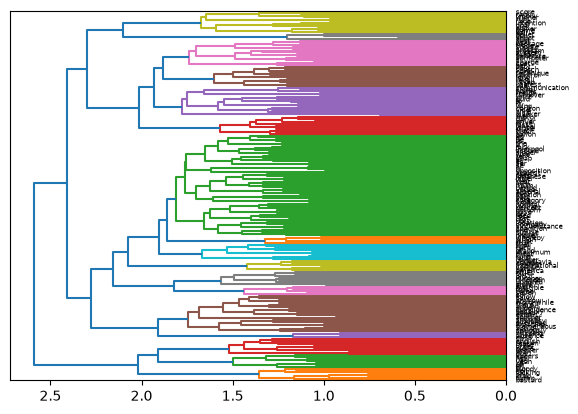

In [10]:
Z = hierarchy.linkage(k['emb'], method="ward")
plt.figure()
hierarchy.dendrogram(Z, orientation="left", labels=k['lemma'])
plt.show()

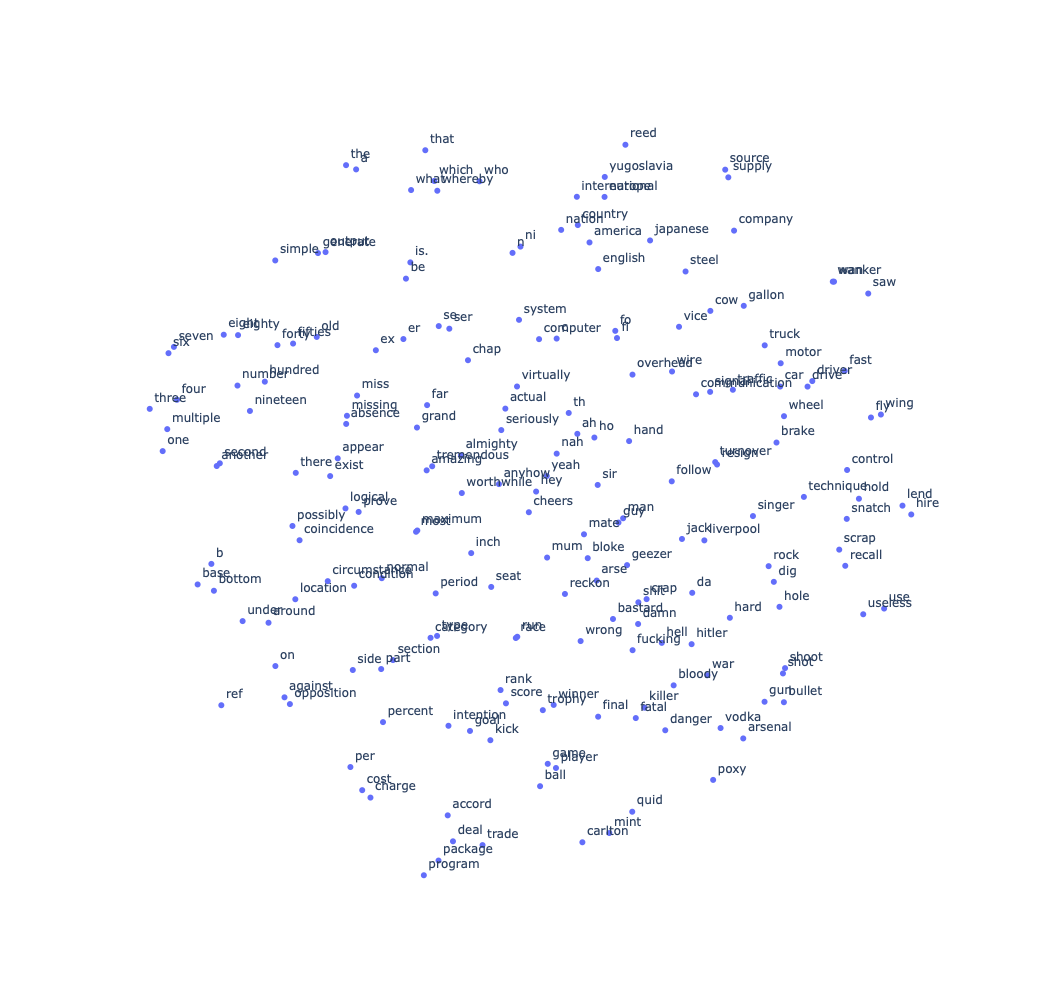

In [17]:
xy = TSNE(2).fit_transform(k['emb'])

fig = plc.text_plot(xy, k['lemma'])
fig.update_layout(height=1000)

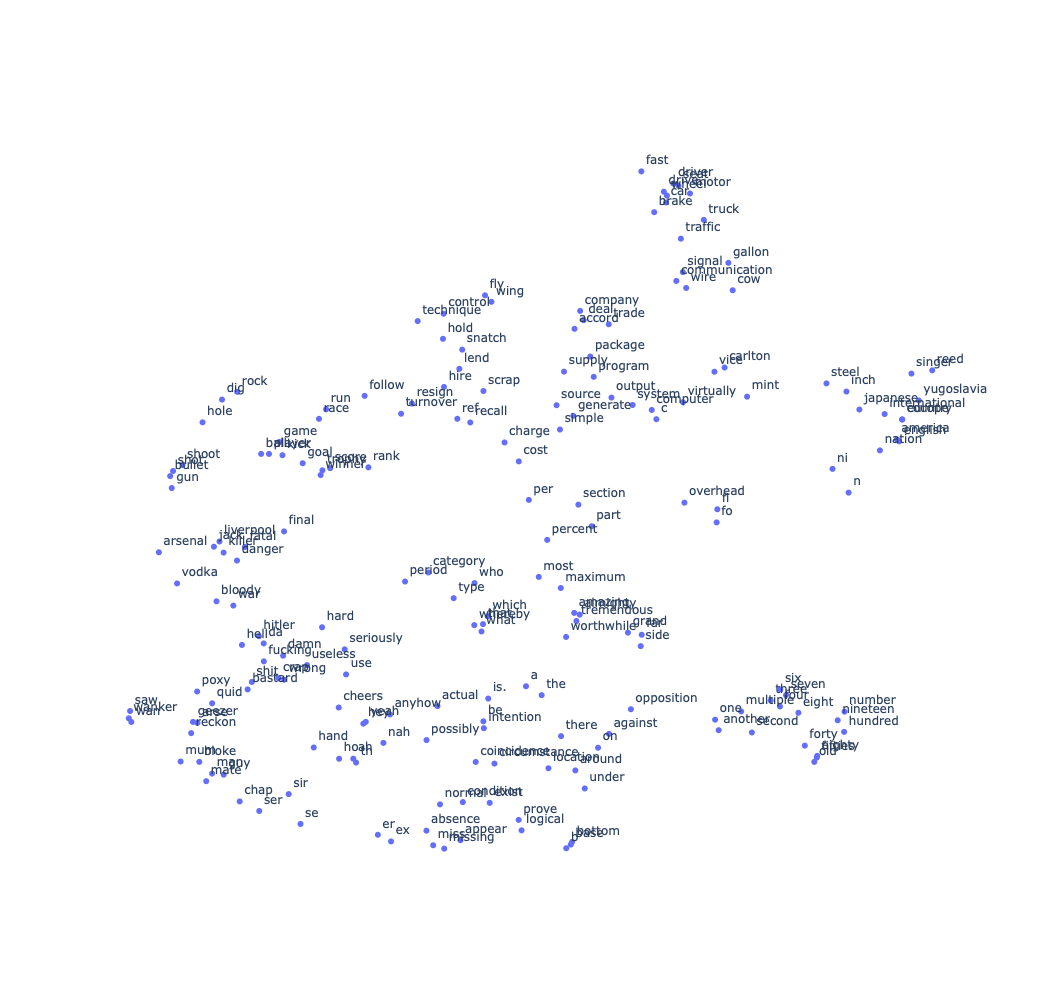

In [18]:
xy = umap.UMAP(n_neighbors=5,n_components=2,init='pca').fit_transform(k['emb'])

fig = plc.text_plot(xy, k['lemma'])
fig.update_layout(height=1000)

In [25]:
plc.search(bnc.collect(), 'hitler').concordance(window=5)

token_left_context,token,token_right_context
list[str],list[str],list[str]
"[""after"", ""life"", ""do"", ""you"", ""reckon""]","[""Hitler""]","[""'s"", ""managed"", ""it"", ""?"", ""no""]"
"[""doing"", ""his"", ""Charlie"", ""Chaplin"", ""or""]","[""Hitler""]","[""impersonations"", ""."", ""You"", ""must"", ""admit""]"
"["","", ""we"", ""laughed"", ""at"", ""bloody""]","[""Hitler""]","[""did"", ""n't"", ""we"", ""?"", ""And""]"
"[""we"", ""could"", ""n't"", ""of"", ""stopped""]","[""Hitler""]","[""<pause/>"", ""Ma"", ""maybe"", ""so"", "",""]"
"[""Do"", ""n't"", ""want"", ""to"", ""find""]","[""Hitler""]","[""'s"", ""only"", ""got"", ""one"", ""ball""]"
"[""<vocal/>"", ""<vocal/>"", ""the"", ""vicar"", ""Adolf""]","[""Hitler""]","[""they"", ""'ve"", ""been"", ""playing"", ""loads""]"
"[""erm"", ""<pause/>"", ""the"", ""next"", ""Mrs""]","[""Hitler""]","["","", ""or"", ""the"", ""next"", ""Mrs""]"
"[""Brom"", ""you"", ""sound"", ""dopey"", ""as""]","[""Hitler""]","["","", ""yes"", ""do"", ""n't"", ""you""]"
"[""that"", ""was"", ""n't"", ""it"", ""<pause/>""]","[""Hitler""]","[""?"", ""<pause/>"", ""You"", ""know"", "",""]"


In [64]:
xy = umap.UMAP(n_neighbors=5,n_components=100,init='pca').fit_transform(k['emb'])
k = k.with_columns(cluster=hdbscan.HDBSCAN(min_cluster_size=5,min_samples=1).fit_predict(xy))
k.sort(by='cluster').group_by("cluster").agg(words=pl.col("lemma").str.join(', '))

cluster,words
i64,str
-1,"""er, per, cost, prove, possibly, charge, ex, actual, anyhow, poxy, logical, arsenal, vodka"""
0,"""hundred, nineteen, three, four, number, forty, one, six, eight, old, second, fifties, multiple, another, seven, eighty"""
1,"""inch, overhead, international, nation, japanese, america, english, ni, steel, europe, fi, fo, singer, country, reed, yugoslavia, n"""
2,"""quid, c, system, simple, computer, supply, accord, mint, trade, company, generate, virtually, vice, package, output, source, carlton, deal, program"""
3,"""brake, fast, gallon, drive, seat, car, motor, signal, wire, cow, driver, communication, truck, wheel, traffic"""
4,"""which, what, period, type, who, category, whereby, that"""
5,"""almighty, wing, most, part, percent, tremendous, worthwhile, section, amazing, fly, maximum"""
6,"""shot, shoot, rock, gun, dig, hole, bullet"""
7,"""ah, hey, yeah, ho, hand, nah, th, cheers"""


In [34]:
%matplotlib widget
